# Analisis de Datos Exploratorio 
En este notebook vamos a dar un primer hallazgo para poder saber con que datos estamos trabajando, saber si hay datos nulos o no normalizados. Y mas que nada poder entender con que nos estamos enfrentando con este proyeto.

El objetivo de este proyecto es poder identificar fraudes bancarios, cuales son los mas comunies y lo mas importante como prevenirlos, se va a estar trabajando con el siguiente base de datos.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/01_raw/PS_20174392719_1491204439457_log.csv')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


Tiene **6362620 filas** y **11 columnas**, el dataset se extrajo de https://www.kaggle.com/datasets/rohit265/fraud-detection-dynamics-financial-transaction el dia 01/06/2026

In [4]:
data.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `step` | Numérico | Unidad de tiempo en el mundo real (1 step = 1 hora). |
| `type` | Categórico | Tipo de transacción (CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER). |
| `amount` | Numérico | El monto de la transacción (Aquí es donde debes aplicar Feature Engineering / Escalamiento). |
| `oldbalanceOrg` | Numérico | Balance inicial de la cuenta de origen antes de la transacción. |
| `newbalanceOrig` | Numérico | Balance nuevo de la cuenta de origen después de la transacción. |
| `oldbalanceDest` | Numérico | Balance inicial del destinatario antes de la transacción. |
| `newbalanceDest` | Numérico | Balance nuevo del destinatario después de la transacción. |
| `isFraud` | Binario (0 o 1) | Tu variable objetivo (Target). Indica si la transacción fue un fraude real. |

Hay que normalizar los datos pata que todas las columnas sean en minusculas, verificar que no haya datos numericos y que en los datos numericos solo haya puros datos numericos.

## Estadistica Descriptiva

In [5]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Como vemos tenemos rango muy diversos en cuestion de las variables numericos.

In [7]:
def coeficiente_gini(array):
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return ((2 * np.sum(index * array)) / (n * np.sum(array))) - ((n + 1) / n)

print(f"Gini (Igualdad): {coeficiente_gini(data['newbalanceDest']):.2f}") 

Gini (Igualdad): 0.79


In [6]:
data.isna().sum().sort_values(ascending=False)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Como se ve, es una base de datos bonita ya que no tenemos datos nulos, muchos de los datos son de tipo float o string por lo que solo hay que reforzar que los datos esten normalizados.

In [7]:
total_duplicados = data.duplicated().sum()
print(f"Total de transacciones duplicadas: {total_duplicados}")

Total de transacciones duplicadas: 0


Al no tener mucho que normalizar o limpiar, signifcia que tenemos una base de datos que tiene una buena calidad de datos, por lo que con esto empezam,os hacer nuestro analisis exploratorio.

## Deteccion de valores atipicos

In [8]:
cuartiles = data['amount'].quantile([0.25, 0.5, 0.75]) 

rango = data['amount'].max() - data['amount'].min()

print(cuartiles)

0.25     13389.5700
0.50     74871.9400
0.75    208721.4775
Name: amount, dtype: float64


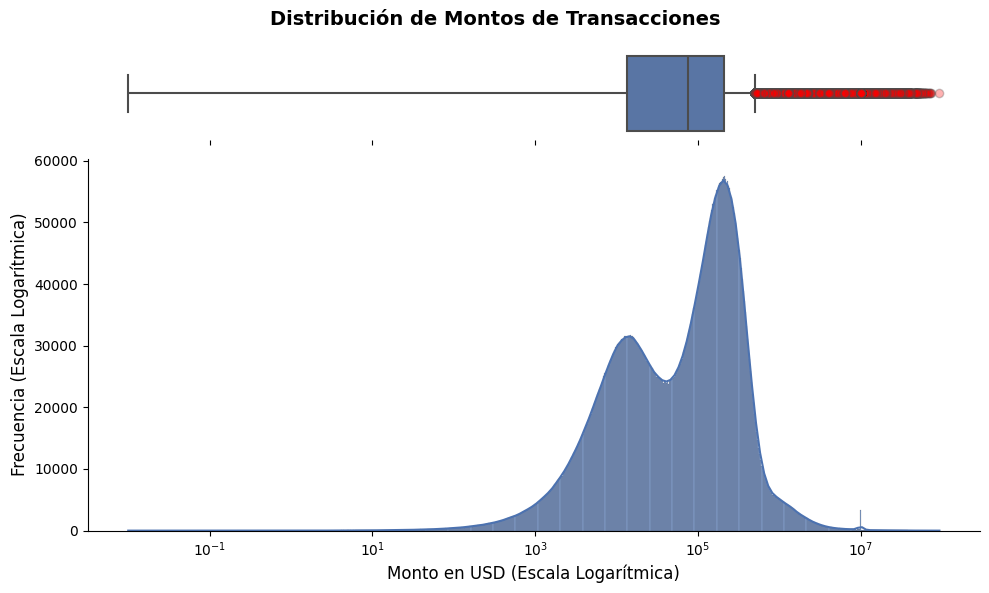

In [29]:
df_plot = data[data["amount"] > 0]

fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": (0.2, 0.8)},
)

sns.boxplot(
    x=df_plot["amount"],
    color="#4C72B0",
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.3},
    ax=ax_box,
)
ax_box.set(xlabel="")  
ax_box.set_xscale("log")  

ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)
ax_box.spines["bottom"].set_visible(False)
ax_box.get_yaxis().set_visible(False)

sns.histplot(
    data=df_plot,
    x="amount",
    color="#4C72B0",
    alpha=0.7,
    kde=True,
    log_scale=True,
    ax=ax_hist
)

ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlabel("Monto en USD (Escala Logarítmica)", fontsize=12)
ax_hist.set_ylabel("Frecuencia (Escala Logarítmica)", fontsize=12)

plt.suptitle(
    "Distribución de Montos de Transacciones",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

Para la representacion de los boplots y la deteccion de valores atipicos vamos a usar una escala logaritmica, esto debido a como en las transacciones que se hacen no llegan de mnaera lineal, si no puede ser que en un momento dentro de  transacciones de 2000 , llegue una transacciones de 10,000 por lo que esto nos generaria un desbalance al momento de tomar la grafica, por lo que lo debemos de hacer en una escala logaritmica para poder ver bien las transacciones pequenas y no queden opacadas por las transacciones grandes.

El análisis de la distribución revela que el comportamiento transaccional típico de nuestros usuarios se concentra entre los $10,000 y $200,000 (rango intercuartílico, Q1 a Q3). La mediana nos indica que el 50 por ciento de todas las operaciones están por debajo de los $100,000 ($10^5$).Ademas de poder ver que hay muchas transacciones que son de montos pequenos por lo que estos los podemos ver normal, ya que la mayoria de las transaccoines no son grandes a diferencia de los outliers que se identificaron. El límite estadístico de lo que consideramos 'normal' alcanza hasta el medio millón de dólares (<$10^6$); a partir de este punto, observamos una gran cantidad de valores atípicos. Dado que estos montos extremos se desvían drásticamente del patrón común, representan un área de alto riesgo y deben ser etiquetados para su investigación como posibles casos de fraude o transferencias corporativas anómalas.

In [10]:
cuartiles = data['oldbalanceOrg'].quantile([0.25, 0.5, 0.75]) 
rango = data['oldbalanceOrg'].max() - data['oldbalanceOrg'].min()
print(cuartiles)

0.25         0.000
0.50     14208.000
0.75    107315.175
Name: oldbalanceOrg, dtype: float64


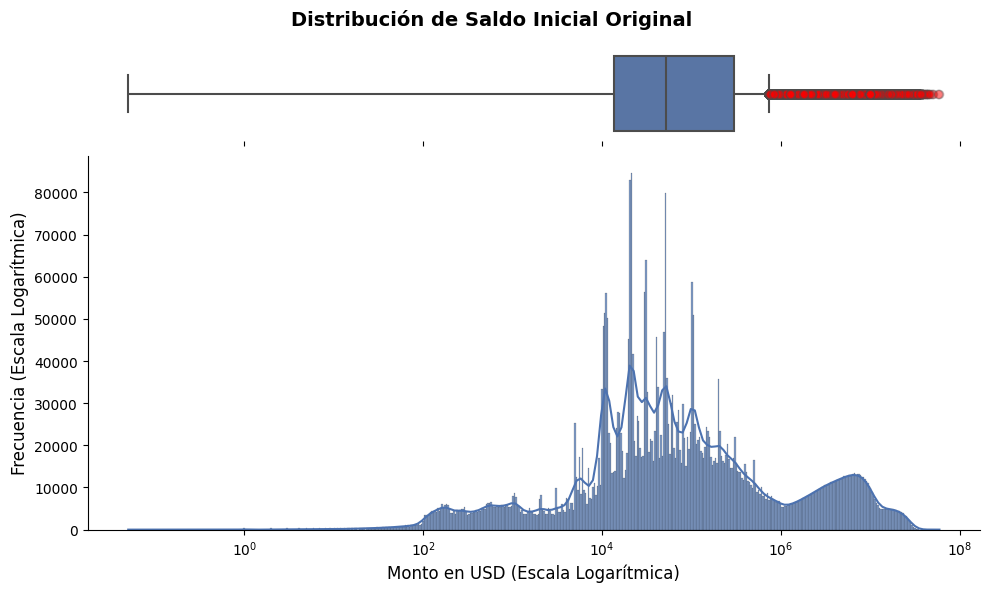

In [28]:
df_plot = data[data["oldbalanceOrg"] > 0]

fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": (0.2, 0.8)},
)

sns.boxplot(
    x=df_plot["oldbalanceOrg"],
    color="#4C72B0",
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.3},
    ax=ax_box,
)
ax_box.set(xlabel="")  
ax_box.set_xscale("log")  

# Limpiar bordes del Boxplot
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)
ax_box.spines["bottom"].set_visible(False)
ax_box.get_yaxis().set_visible(False)

sns.histplot(
    data=df_plot, 
    x="oldbalanceOrg",
    color="#4C72B0",
    alpha=0.7,
    kde=True,  
    log_scale=True,
    ax=ax_hist,
)

ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlabel("Monto en USD (Escala Logarítmica)", fontsize=12)
ax_hist.set_ylabel("Frecuencia (Escala Logarítmica)", fontsize=12)

plt.suptitle(
    "Distribución de Saldo Inicial Original ",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

Al analizar el saldo previo de las cuentas de origen (oldbalanceOrg), observamos que el comportamiento habitual de nuestros usuarios se concentra entre los 10,000 y poco más de 100,000 dólares (rango Q1-Q3). Ademas de que la mayoria de nuestro sueldo incial esta en porciones muy bajas debajo del Q1. La mediana nos indica que la mitad exacta de las cuentas tiene un saldo que supera por poco los 10,000 dólares. El límite estadístico superior de lo que consideramos un saldo 'común' se extiende hasta valores cercanos al millón de dólares (< 10^6). Por encima de este umbral, detectamos valores atípicos significativos correspondientes a cuentas con fondos mucho mayores. Nuestra hipótesis es que estos montos excepcionales no son necesariamente anomalías de riesgo, sino que representan cuentas de ahorro consolidadas, clientes de alto patrimonio o cuentas de naturaleza corporativa. Sin embargo pueden ser cuentas objetivos o mas propensas a ataques debido a la cantidad de dinero que guardan.

In [12]:
cuartiles = data['newbalanceOrig'].quantile([0.25, 0.5, 0.75]) 
rango = data['newbalanceOrig'].max() - data['newbalanceOrig'].min()
print(cuartiles)

0.25         0.00
0.50         0.00
0.75    144258.41
Name: newbalanceOrig, dtype: float64


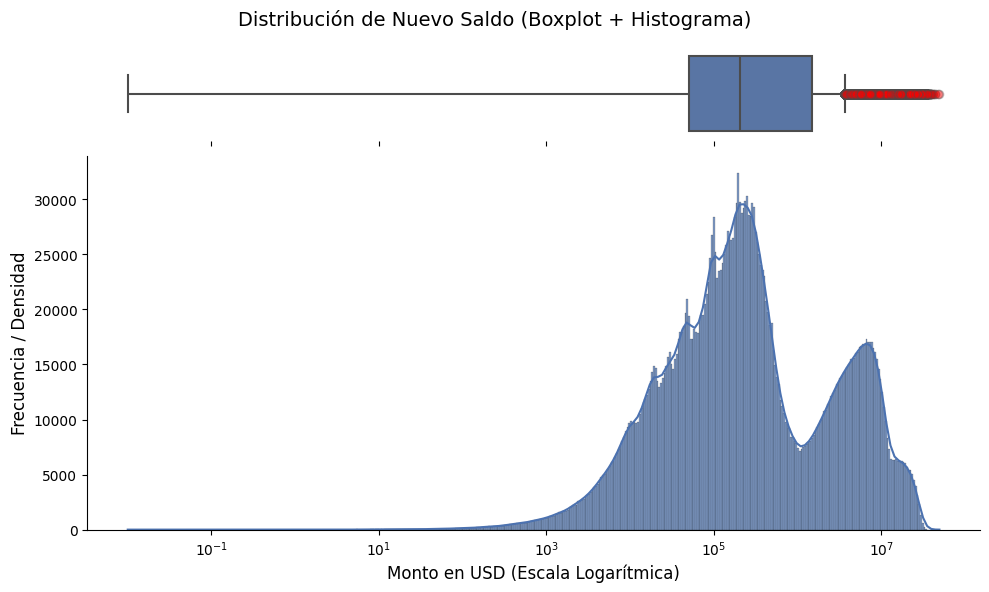

In [ ]:

df_plot = data[data["newbalanceOrig"] > 0]


fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": (0.2, 0.8)},
)


sns.boxplot(
    x=df_plot["newbalanceOrig"],
    color="#4C72B0",
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.3},
    ax=ax_box,
)
ax_box.set(xlabel="")  
ax_box.set_xscale("log")  

ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)
ax_box.spines["bottom"].set_visible(False)
ax_box.get_yaxis().set_visible(False)


sns.histplot(
    data=df_plot, 
    x="newbalanceOrig",
    color="#4C72B0",
    alpha=0.7,
    kde=True,  
    log_scale=True,
    ax=ax_hist,
)

ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlabel("Monto en USD (Escala Logarítmica)", fontsize=12)
ax_hist.set_ylabel("Frecuencia / Densidad", fontsize=12)

plt.suptitle(
    "Distribución de Nuevo Saldo Original ",
    fontsize=14,
    y=0.98,
)

plt.tight_layout()
plt.show()

Al final de las transacciones se tiene que el nuevo balance de las cuentas originales se dismunyte en una gran cantidad, ya que tenemos muchos alores atipicos que son las cuentas donde aun se mantien estas grandes cantidades de dinero. Donde la mayoria del nuevo saldo iriginal se encunetra debahoi del Q2 debajo de 10^4 por teniendo mas donde no muchos regitsros se encuntran entre el q2 y la mediana pero batsantes registros que represntan el 75% sson menores de 10^6 por lo que se indica que hay muchas transacciones cdentro de este rango, sin mebargo podemos ver que a partir de 10 ^ 6 se encuentran valores atipicos sqiue se salen de nuestro rango quartilico.

In [14]:
cuartiles = data['oldbalanceDest'].quantile([0.25, 0.5, 0.75]) 
rango = data['oldbalanceDest'].max() - data['oldbalanceDest'].min()
print(cuartiles)

0.25         0.0000
0.50    132705.6650
0.75    943036.7075
Name: oldbalanceDest, dtype: float64


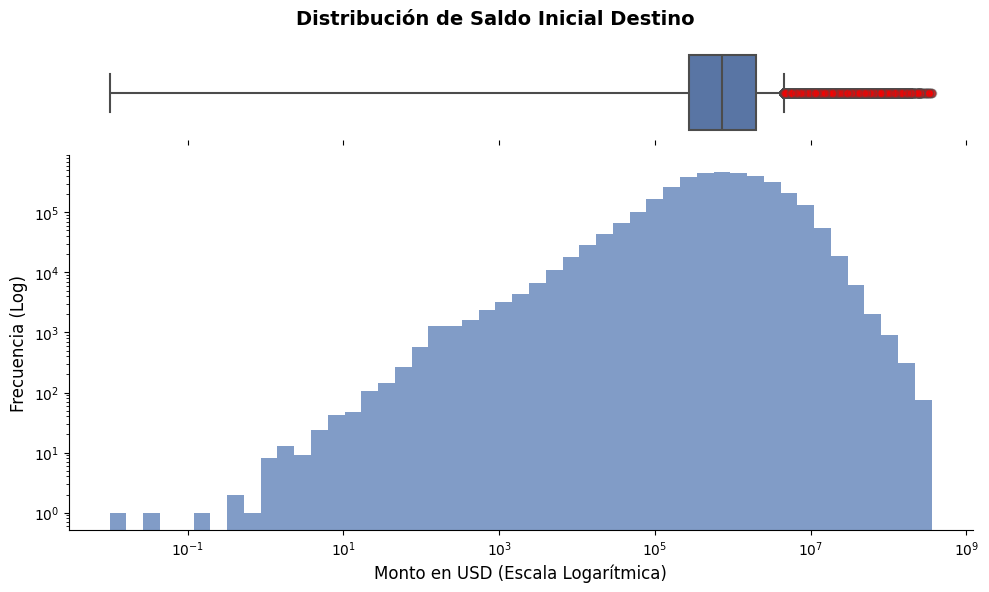

In [35]:
df_plot = data[data["oldbalanceDest"] > 0]

fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": (0.2, 0.8)},
)


sns.boxplot(
    x=df_plot["oldbalanceDest"],
    color="#4C72B0",
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.3},
    ax=ax_box,
)
ax_box.set(xlabel="")  
ax_box.set_xscale("log")  

ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)
ax_box.spines["bottom"].set_visible(False)
ax_box.get_yaxis().set_visible(False)


min_val = df_plot["oldbalanceDest"].min()
max_val = df_plot["oldbalanceDest"].max()

bins_log = np.logspace(np.log10(min_val), np.log10(max_val), 50)

ax_hist.hist(
    df_plot["oldbalanceDest"], 
    bins=bins_log, 
    color="#4C72B0", 
    alpha=0.7, 
    log=True 
)

ax_hist.set_xscale("log")

ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlabel("Monto en USD (Escala Logarítmica)", fontsize=12)
ax_hist.set_ylabel("Frecuencia (Log)", fontsize=12)

plt.suptitle(
    "Distribución de Saldo Inicial Destino",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

Ha picos mas altos que se estan alineando entre  entre 10^5 y 10^6, por lo que puede ser que estas cuentas como ya se dijo que ya cuenten con un capital registrado, como ahorros o que sea fuernte de comercios, dando que el 25% de las trasnacciones son menores a al Q2, por lo que la mayoria de trasnacciones menores, mientras que en el 50% se tiene que son transacciones entre 10^5 y 10^7 como ya se menciono, ya teniendo como maximo dentro del rango inerquantil como 10^7, sin mebrago tenemos muchos outliers.

In [16]:
cuartiles = data['newbalanceDest'].quantile([0.25, 0.5, 0.75]) 
rango = data['newbalanceDest'].max() - data['newbalanceDest'].min()
print(cuartiles)

0.25          0.00
0.50     214661.44
0.75    1111909.25
Name: newbalanceDest, dtype: float64


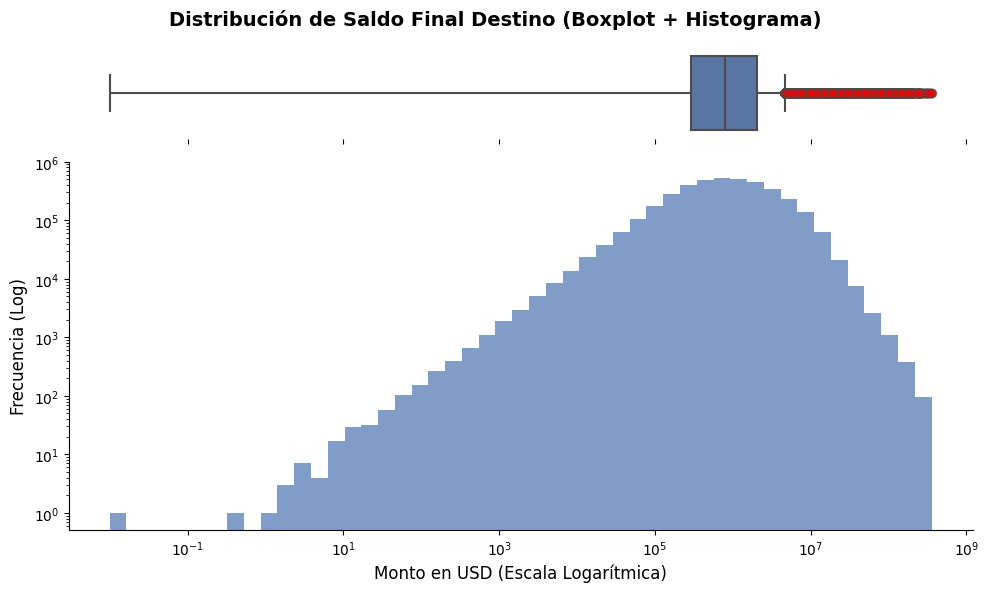

In [ ]:
df_plot = data[data["newbalanceDest"] > 0]

fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": (0.2, 0.8)},
)

sns.boxplot(
    x=df_plot["newbalanceDest"],
    color="#4C72B0",
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.3},
    ax=ax_box,
)
ax_box.set(xlabel="")  
ax_box.set_xscale("log")  

ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)
ax_box.spines["bottom"].set_visible(False)
ax_box.get_yaxis().set_visible(False)

min_val = df_plot["newbalanceDest"].min()
max_val = df_plot["newbalanceDest"].max()

bins_log = np.logspace(np.log10(min_val), np.log10(max_val), 50)

ax_hist.hist(
    df_plot["newbalanceDest"], 
    bins=bins_log, 
    color="#4C72B0", 
    alpha=0.7, 
    log=True 
)

ax_hist.set_xscale("log")

ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlabel("Monto en USD (Escala Logarítmica)", fontsize=12)
ax_hist.set_ylabel("Frecuencia (Log)", fontsize=12)

plt.suptitle(
    "Distribución de Saldo Final Destino",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

Ha picos mas altos que se estan alineando entre  entre 10^5 y 10^6, por lo que puede ser que estas cuentas como ya se dijo que ya cuenten con un capital registrado, como ahorros o que sea fuernte de comercios, dando que el 25% de las trasnacciones son menores a al Q2, por lo que la mayoria de trasnacciones menores, mientras que en el 50% se tiene que son transacciones entre 10^5 y 10^7 como ya se menciono, ya teniendo como maximo dentro del rango inerquantil como 10^7, sin mebrago tenemos muchos outliers.

Estamos identificando por que las graficas de saldo inicial y final de la cuenta de destino se parecen.

Esto se peude er ya que al estar haciendo transacciones a cuentas que ya tienen una cnatidad generosa, esto nos e va a ver reflejado, adeasm si las transacciones son de 1000 agregandolo a una cuenta que tiene 2,000,000 no se a ver mucha la diferencia y la escala logaritmica refuerza mas esto.

## Distribuciones

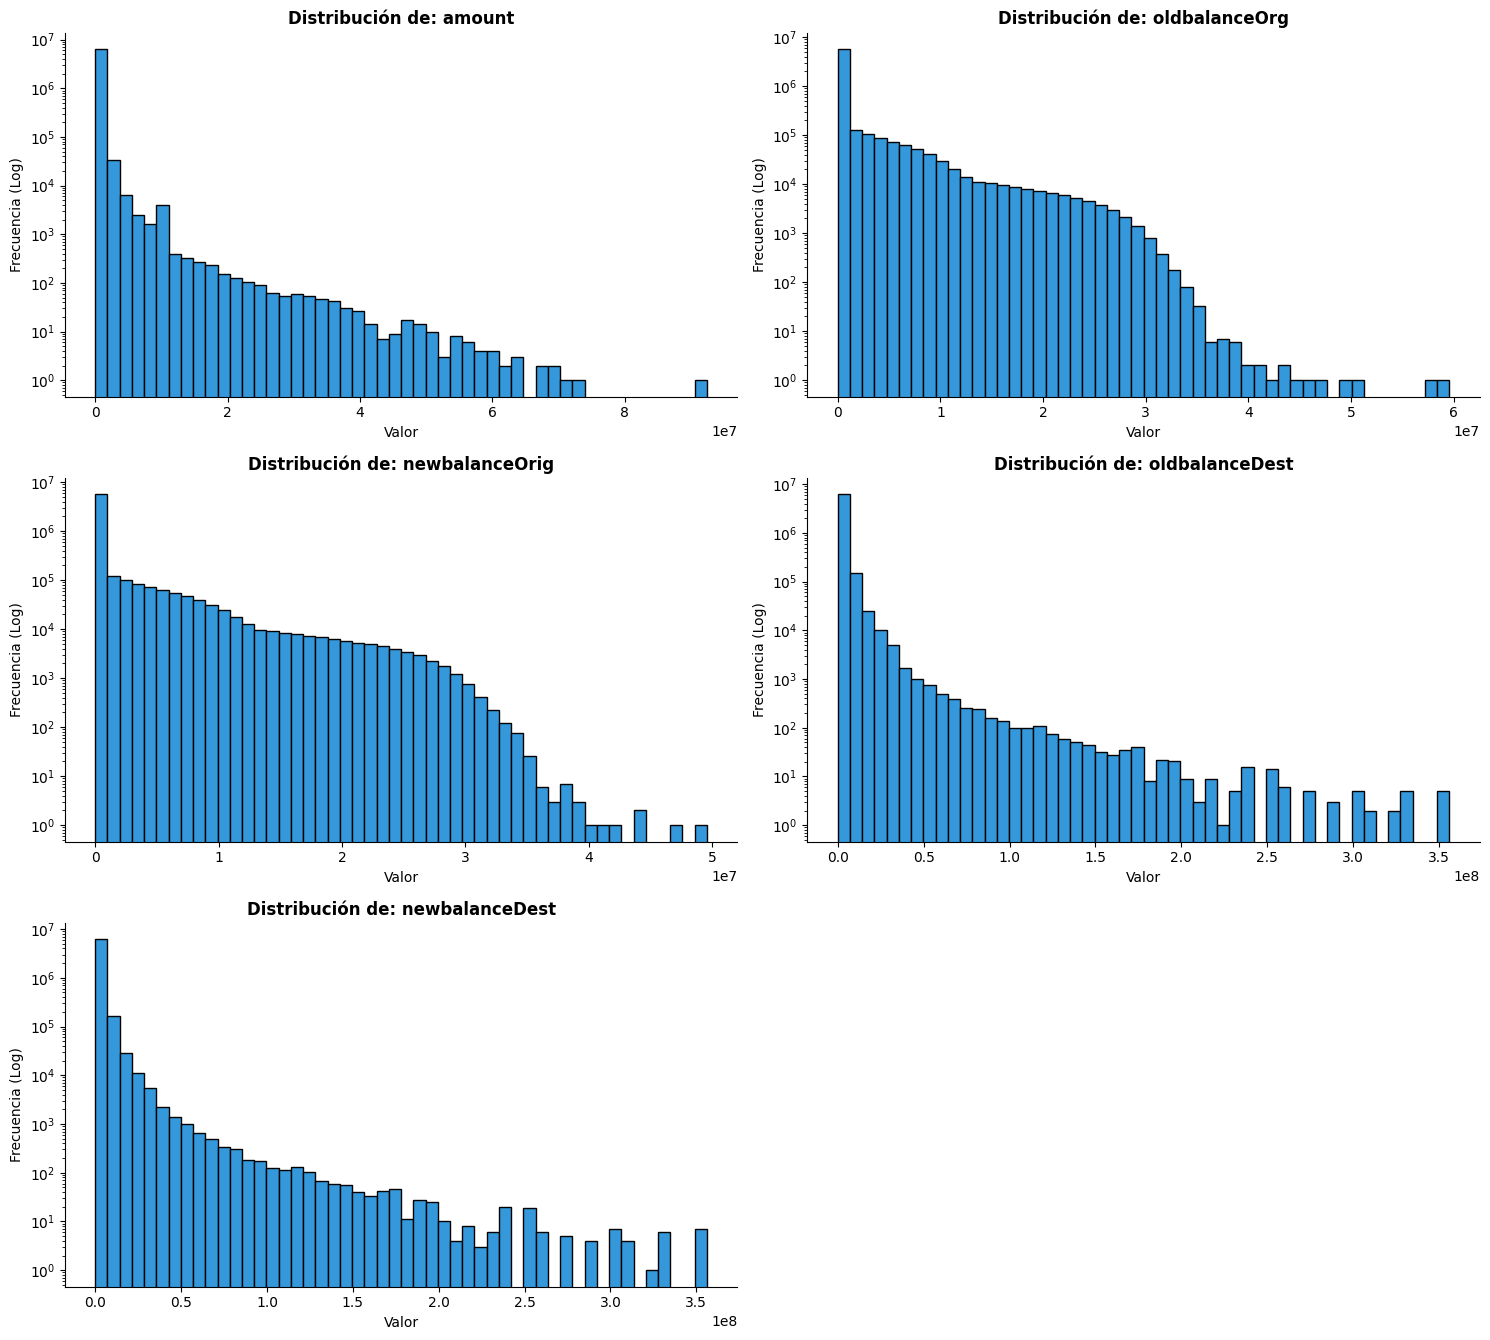

In [18]:
import math

columnas_excluir = ['isFraud', 'isFlaggedFraud', 'step'] 
columnas_numericas = data.select_dtypes(include=['number']).columns.tolist()
vars_relevantes = [col for col in columnas_numericas if col not in columnas_excluir]

filas = math.ceil(len(vars_relevantes) / 2)
fig, axes = plt.subplots(filas, 2, figsize=(15, filas * 4.5))
axes = axes.flatten() 


for i, columna in enumerate(vars_relevantes):
    axes[i].hist(data[columna].dropna(), bins=50, color='#3498db', edgecolor='black')
    
    axes[i].set_yscale('log')
    
    axes[i].set_title(f'Distribución de: {columna}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=10)
    axes[i].set_ylabel('Frecuencia (Log)', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Como vemos la mayoria de las transacciones y el banace de las cuentas de origen y destino estan sesgadas a la derecha, ya que todos se estan aglomerando en la izquierda. Como tenemos los datos sesgados debemos de aplicar una transformacion para el entrenamiento de nuestro mdoelo y se debe de escalar para no entrenar mal el modelo.

## Relaciones entre Variables

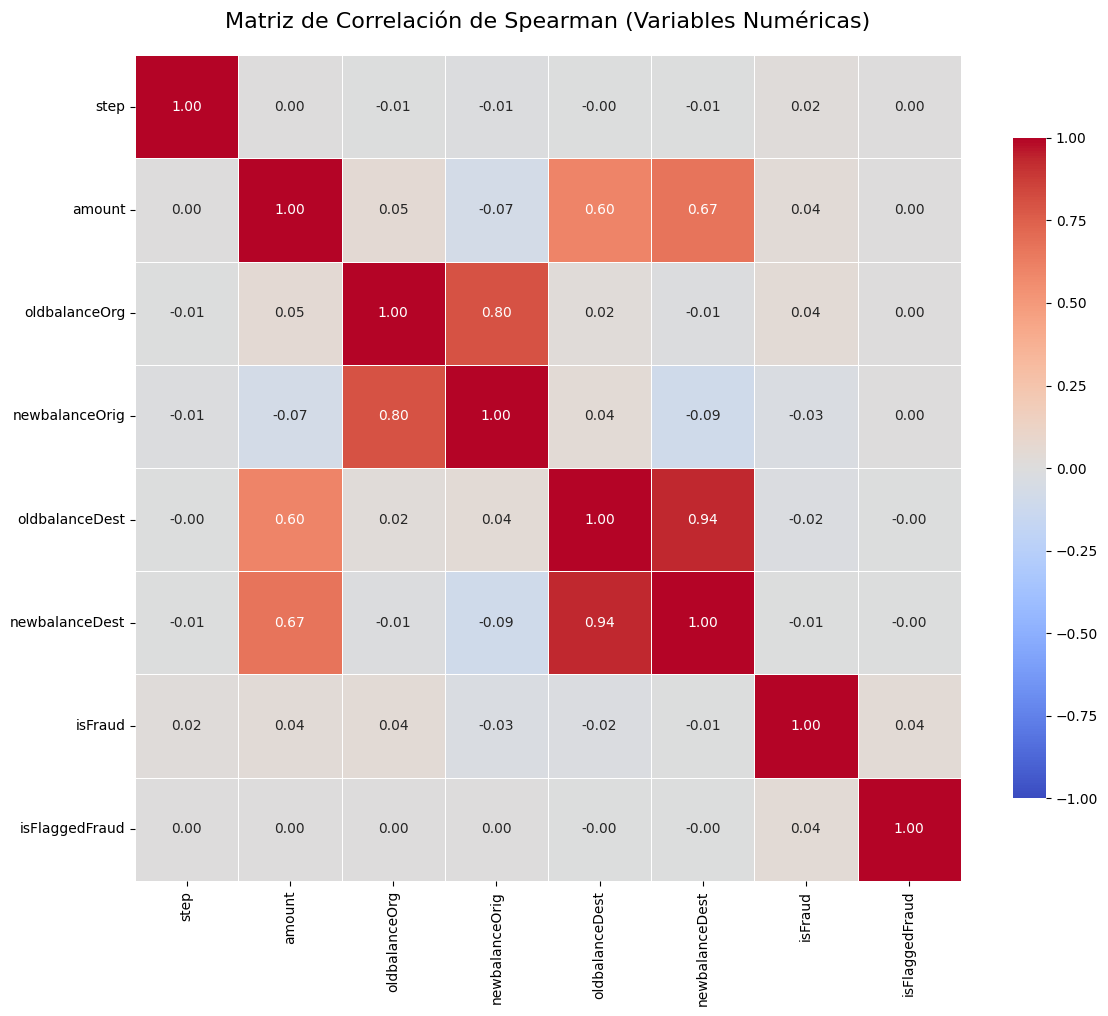

In [ ]:
df_numerico = data.select_dtypes(include=['number'])

matriz_corr = df_numerico.corr(method='spearman')


plt.figure(figsize=(12, 10))


sns.heatmap(
    matriz_corr, 
    annot=True,        
    fmt=".2f",        
    cmap="coolwarm",   
    vmin=-1, vmax=1, 
    square=True,     
    linewidths=0.5,    
    cbar_kws={"shrink": .8} 
)

plt.title('Matriz de Correlación de Spearman (Variables Numéricas)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Como se puede observar en el mapa de calor, las correlaciones más fuertes se presentan entre el monto de la transacción  y los balances iniciales y finales de la cuenta de origen, aunque no es tan fuerte a comparacion de otras relaciones. De igual manera, existe una relación directa y recíproca entre los balances previos y posteriores de la cuenta de destino. Esto es analíticamente coherente, ya que el flujo monetario altera directamente los saldos mediante operaciones de suma o resta en ambas entidades.

Asimismo, destaca la relación entre el monto transferido y la variación del saldo en la cuenta receptora. Este comportamiento abre una oportunidad clave para identificar anomalías donde una cuenta históricamente con fondos mínimos recibe un repunte súbito y drástico de capital, un patrón característico en escenarios de fraude o extorsión.

## Análisis de variables categóricas

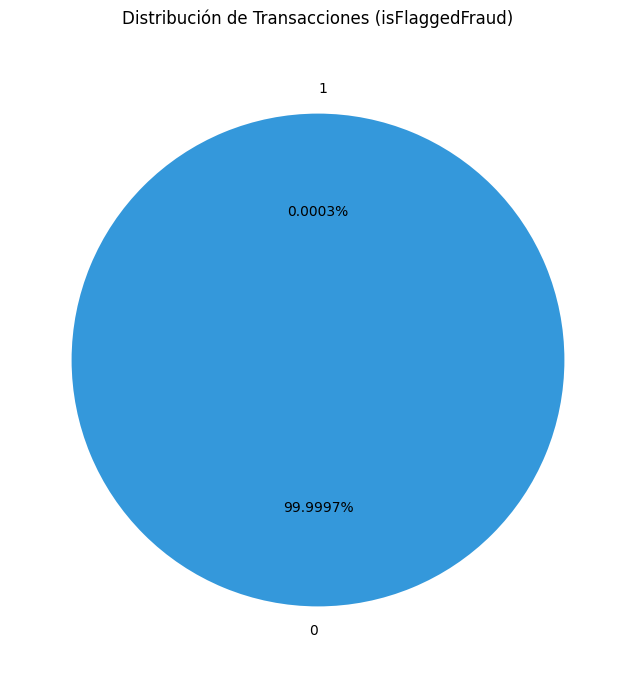

In [ ]:
# Obtener los conteos
conteo_isflagged = data['isFlaggedFraud'].value_counts()

# Crear la gráfica de pastel
conteo_isflagged.plot(
    kind='pie', 
    figsize=(8, 8), 
    colors=['#3498db', '#e74c3c'], 
    autopct='%1.4f%%',             
    startangle=90                
)

plt.title('Distribución de Transacciones (isFlaggedFraud)', pad=20)
plt.ylabel('') 

# Mostrar el gráfico
plt.show()

Tenemos un desbalanceo en nuestra base de datos, ya que tenemos que el 0.0003 son fraudes, esto es como la mayoria de veces pasa en casos de la vida real, por que debemos de tener una buena deteccion sobre esto, esta columna es conforme a lo que el negocio establece.

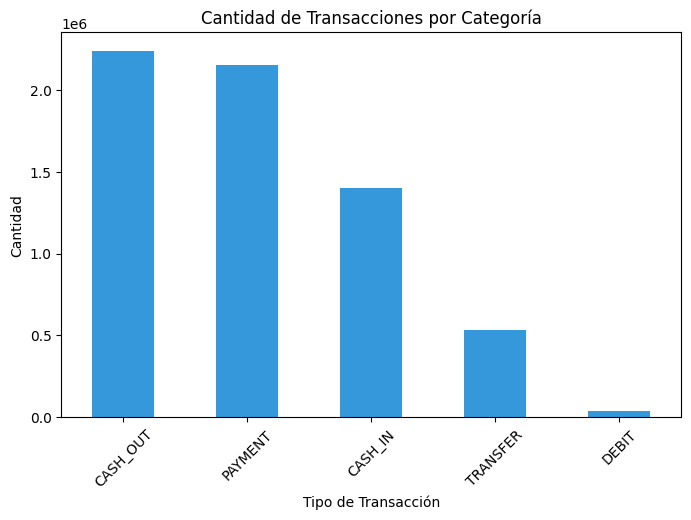

In [21]:
conteo_categorias = data['type'].value_counts()

conteo_categorias.plot(kind='bar', color='#3498db', figsize=(8, 5))

plt.title('Cantidad de Transacciones por Categoría')
plt.xlabel('Tipo de Transacción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) 
plt.show()

La mayor parte de las transacciones son de tupo de cast out seguido por el pago de cuentas y como tercer lugar se tiene las operaciones de cash in. 

### Por que es impotante identificar el tipo de transaccion que tiene mayor movimiento?

El fraude tiene tipos de transacciones favoritos donde los delincuentes no usan todos los métodos por igual. Y esto lo podemos ver en la grafica donde casi todas las transferencias son de cash out y de payment, es decir que el dinero sale. Como se ha estado viendo conforme al conetxto del fraude la manera mas facil de hacer el fraude es mediante cash out. Ya que en el cash out,  una vez que el dinero está en la cuenta del criminal, este corre a un cajero automático o ventanilla a sacarlo en efectivo. Al volverse efectivo físico, el dinero se vuelve irreastreable. Y transfer porque en este mundo digital es mas facil hacer una transferecnia que llegue el dinero a la otra cuenta sin tener la seguridad que realmente estas pagando a una persona confiable.


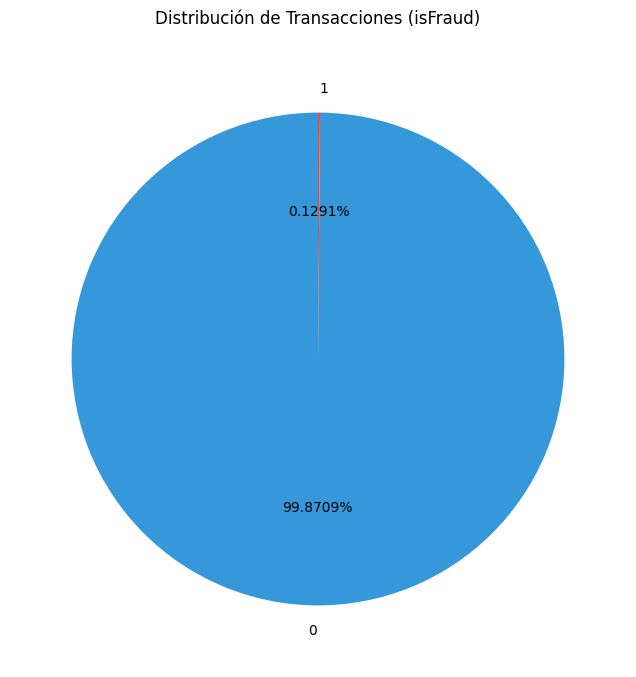

In [40]:
# Obtener los conteos
conteo_isfraud = data['isFraud'].value_counts()

# Crear la gráfica de pastel
conteo_isfraud.plot(
    kind='pie', 
    figsize=(8, 8), 
    colors=['#3498db', '#e74c3c'], 
    autopct='%1.4f%%',           
    startangle=90                
)

plt.title('Distribución de Transacciones (isFraud)', pad=20)
plt.ylabel('') 

plt.show()

Como pasa en el anterior caso tenemos una base de datos desbalanceado donde el 0.12% son fraudes, por lo que tenemos una base de datos que simula como es la deteccion de anomalias y el caso de ellas en la vida real

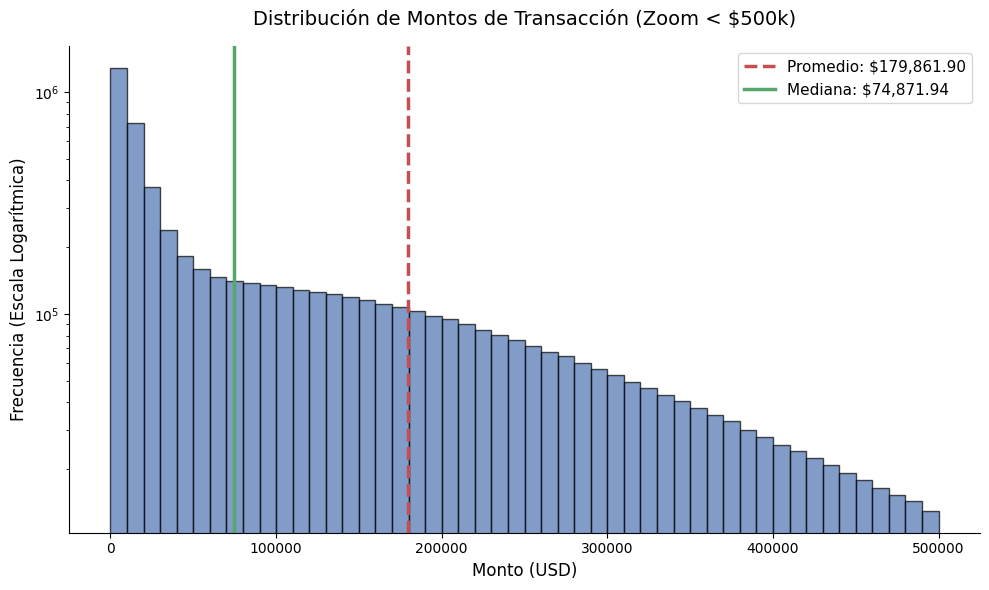

In [23]:
promedio = data['amount'].mean()
mediana = data['amount'].median()

plt.figure(figsize=(10, 6))
    

limite_visual = 500000 
plt.hist(data['amount'], bins=50, range=(0, limite_visual), 
         color='#4C72B0', edgecolor='black', alpha=0.7)

plt.axvline(promedio, color='#C44E52', linestyle='dashed', linewidth=2.5, 
            label=f'Promedio: ${promedio:,.2f}')
plt.axvline(mediana, color='#55A868', linestyle='solid', linewidth=2.5, 
            label=f'Mediana: ${mediana:,.2f}')


plt.yscale('log')


plt.title('Distribución de Montos de Transacción (Zoom < $500k)', fontsize=14, pad=15)
plt.xlabel('Monto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Mostrar leyenda y ajustar diseño
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

C:\Users\emmaj\AppData\Local\Temp\ipykernel_14604\3888787474.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


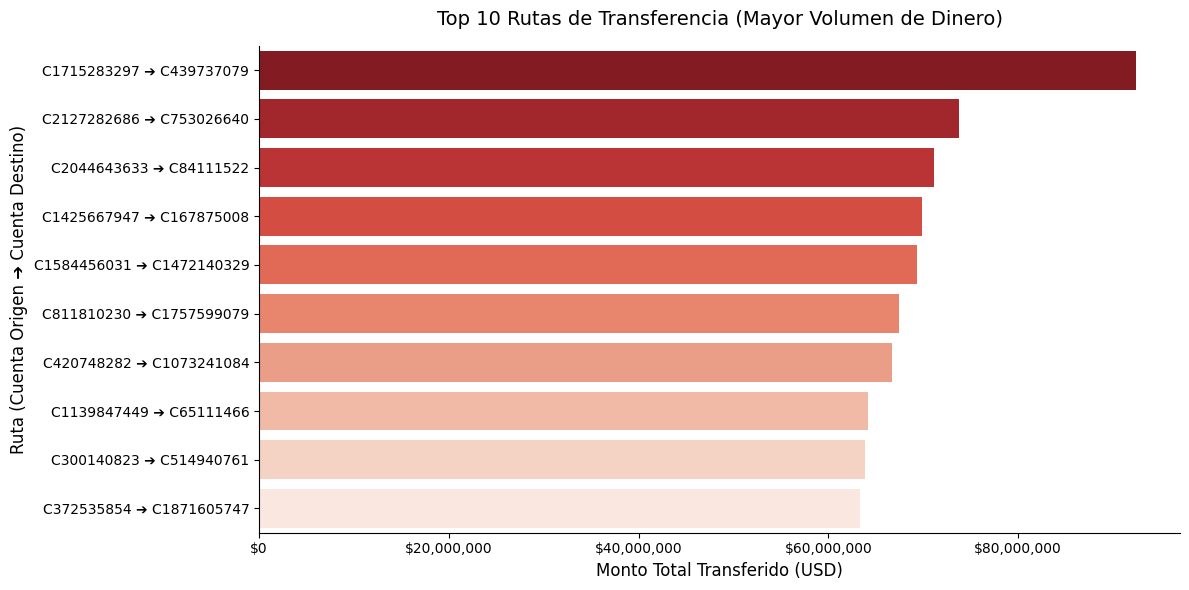

In [ ]:

data['ruta_transferencia'] = data['nameOrig'].astype(str) + " ➔ " + data['nameDest'].astype(str)


top_rutas = data.groupby('ruta_transferencia')['amount'].sum().nlargest(10).reset_index()


plt.figure(figsize=(12, 6))


sns.barplot(
    x='amount', 
    y='ruta_transferencia', 
    data=top_rutas, 
    palette='Reds_r'
)


plt.title('Top 10 Rutas de Transferencia (Mayor Volumen de Dinero)', fontsize=14, pad=15)
plt.xlabel('Monto Total Transferido (USD)', fontsize=12)
plt.ylabel('Ruta (Cuenta Origen ➔ Cuenta Destino)', fontsize=12)


ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:,.0f}'))


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Las transferencias de la cuenta de origen a la cuenta de destino, siendo las transacciones mas populares se han hecho en estasn cuentas, siendo las cuentas con mayor volumen de dinero transferido, con esto podemos identificar las cuentas y montos con mayor transaccion dependiendo de como sean los movimientos de la cuenta general y poder destapar estos casos de fraudes identificando los patrones de las cuentas con un mayor monto transferido.

C:\Users\emmaj\AppData\Local\Temp\ipykernel_14604\776167519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\emmaj\AppData\Local\Temp\ipykernel_14604\776167519.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])


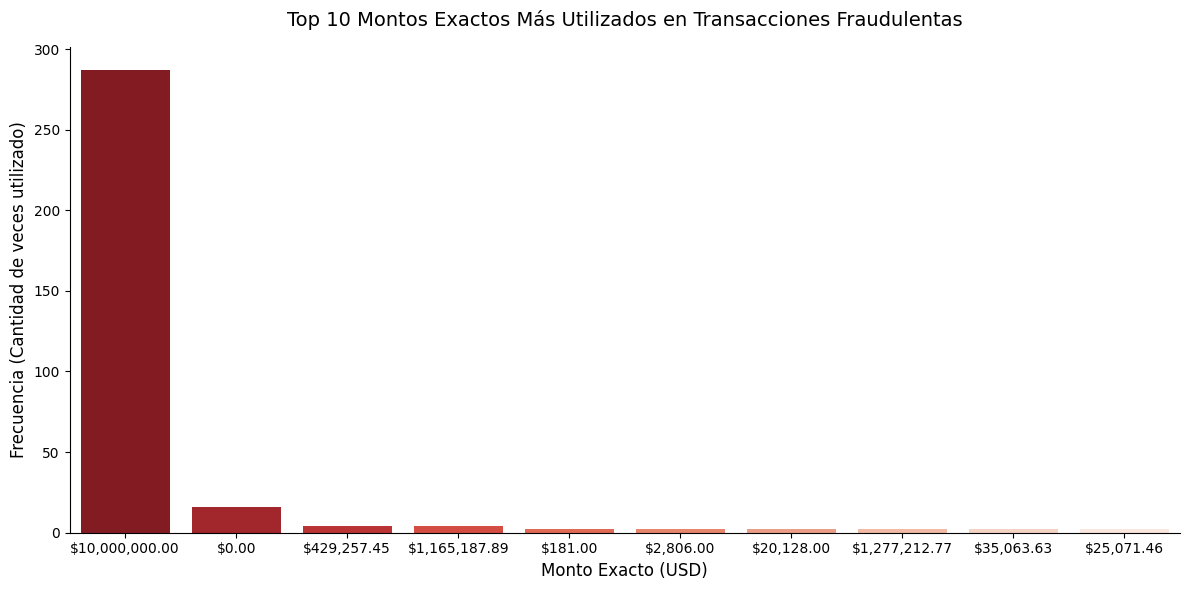

In [ ]:
df_solo_fraudes = data[data['isFraud'] == 1]


montos_comunes = df_solo_fraudes['amount'].value_counts().head(10).reset_index()
montos_comunes.columns = ['monto_exacto', 'cantidad_de_fraudes']


plt.figure(figsize=(12, 6))


sns.barplot(
    x=montos_comunes['monto_exacto'].astype(str), 
    y=montos_comunes['cantidad_de_fraudes'], 
    palette='Reds_r' 
)


plt.title('Top 10 Montos Exactos Más Utilizados en Transacciones Fraudulentas', fontsize=14, pad=15)
plt.xlabel('Monto Exacto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de veces utilizado)', fontsize=12)


ax = plt.gca()
ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Dentro de las transacciones que se sabe que son fraudulenmtas vemos que el monto mas comun es de 10,000,000 doalres, por lo que transacciones de este tipo son las que se deben de monitorear mas a profundidad, al igual que las transacciones de 0 pesos que son bastantes y ya haciendo un analisis de estas, estan clasificadas como fraudes.

C:\Users\emmaj\AppData\Local\Temp\ipykernel_14604\2745930796.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\emmaj\AppData\Local\Temp\ipykernel_14604\2745930796.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])


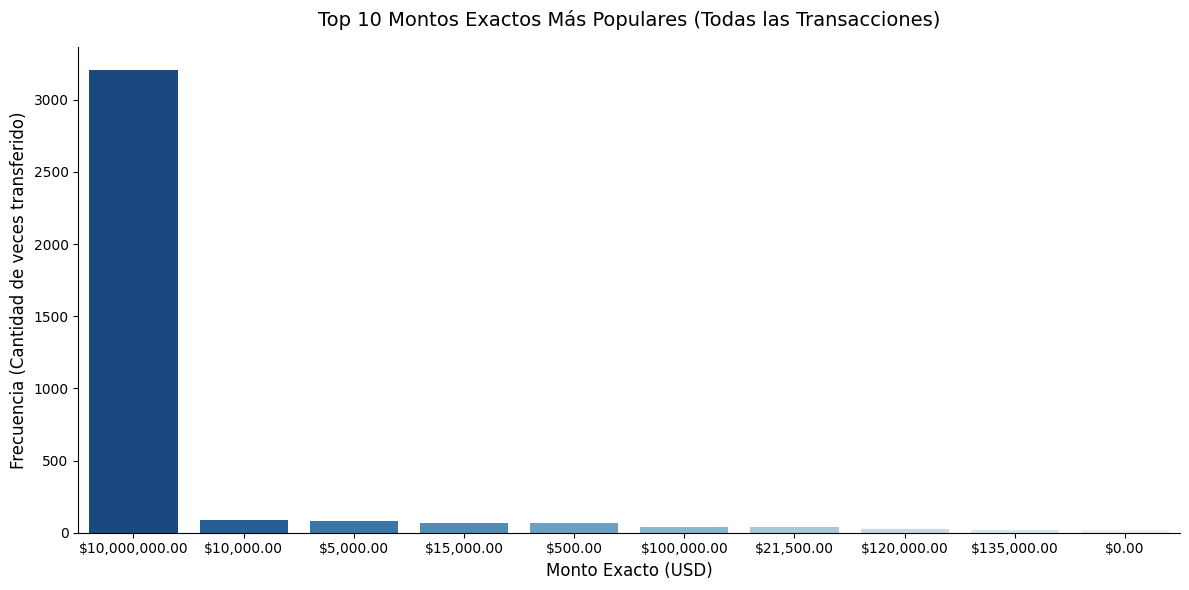

In [ ]:

montos_comunes = data['amount'].value_counts().head(10).reset_index()


montos_comunes.columns = ['monto_exacto', 'frecuencia']


plt.figure(figsize=(12, 6))


sns.barplot(
    x=montos_comunes['monto_exacto'].astype(str), 
    y=montos_comunes['frecuencia'], 
    palette='Blues_r' 
)


plt.title('Top 10 Montos Exactos Más Populares (Todas las Transacciones)', fontsize=14, pad=15)
plt.xlabel('Monto Exacto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de veces transferido)', fontsize=12)


ax = plt.gca()
ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Con esto vemos que la mayoria de transacciones que se estam haciendo son de monto de 10,000,000 dolares por lo que podria deber se a intentos de fraudes con la suma muy larag de dinero, siendo asi que existen mas de 3000 transferencias de este tipo.

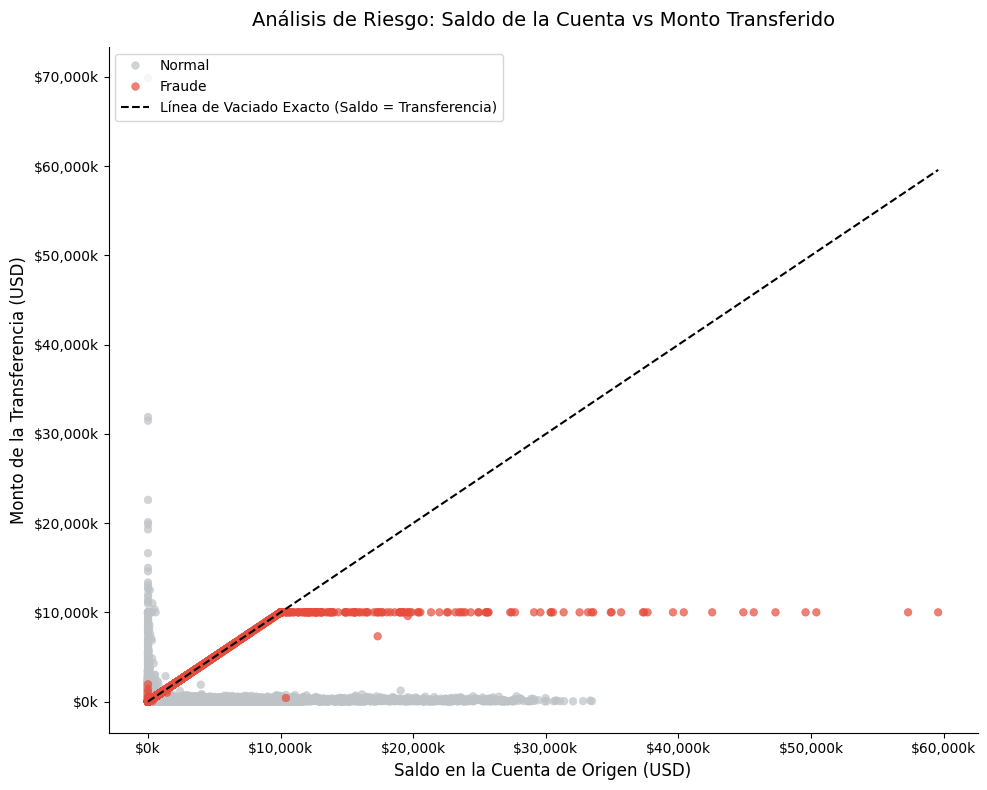

In [ ]:

df_fraudes = data[data['isFraud'] == 1]
df_normales = data[data['isFraud'] == 0].sample(n=50000, random_state=42)


df_plot = pd.concat([df_normales, df_fraudes])


df_plot['Tipo de Transacción'] = df_plot['isFraud'].map({0: 'Normal', 1: 'Fraude'})


plt.figure(figsize=(10, 8))


sns.scatterplot(
    data=df_plot,
    x='oldbalanceOrg',  
    y='amount',         
    hue='Tipo de Transacción',
    palette={'Normal': '#BDC3C7', 'Fraude': '#E74C3C'}, 
    alpha=0.7,          
    s=30,               
    edgecolor=None
)


max_val = min(df_plot['oldbalanceOrg'].max(), df_plot['amount'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1.5, 
         label='Línea de Vaciado Exacto (Saldo = Transferencia)')


plt.title('Análisis de Riesgo: Saldo de la Cuenta vs Monto Transferido', fontsize=14, pad=15)
plt.xlabel('Saldo en la Cuenta de Origen (USD)', fontsize=12)
plt.ylabel('Monto de la Transferencia (USD)', fontsize=12)


ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:,.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:,.0f}k'))


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.legend(loc='upper left')
plt.tight_layout()

plt.show()